In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# LIBRERIAS

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})


# CARGA DE DATOS

In [41]:
# CARGA DE DATOS:
CARPETA_RAIZ = '/content/drive/MyDrive/DAS_ENTREGABLE1/'
ruta_dataset = '/content/drive/MyDrive/DAS_ENTREGABLE1/Accidentes de tránsito en carreteras-2020-2021-Sutran.csv'

# Añadimos sep=';' para separar las columnas y encoding='latin-1' para las tildes
df = pd.read_csv(ruta_dataset, sep=';', encoding='latin-1')

df.head()

,FECHA_CORTE,FECHA,HORA,DEPARTAMENTO,CODIGO_VÍA,KILOMETRO,MODALIDAD,FALLECIDOS,HERIDOS
0,20211222,20200101,05:40,LIMA,PE-1S,24,DESPISTE,0,0
1,20211222,20200101,16:30,CAJAMARCA,PE-3N,74,DESPISTE,0,0
2,20211222,20200101,07:45,PASCO,PE-3N,103,DESPISTE,0,1
3,20211222,20200101,18:30,CAJAMARCA,PE-08,111,DESPISTE,0,2
4,20211222,20200101,18:40,LIMA,PE-1N,174,DESPISTE,0,5


# DIMENSION DEL DATAFRAME

In [42]:
#CANTIDAD DE DATOS DE LA TABLA
print(f"El dataset tiene",df.shape[0],"filas y",df.shape[1],"columnas")

El dataset tiene 8155 filas y 9 columnas


#INFORMACION DEL DATAFRAME
Se observa el tipo de datos, y la cantidad de nulos.

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8155 entries, 0 to 8154
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   FECHA_CORTE   8155 non-null   int64 
 1   FECHA         8155 non-null   int64 
 2   HORA          8155 non-null   object
 3   DEPARTAMENTO  8155 non-null   object
 4   CODIGO_VÍA    8155 non-null   object
 5   KILOMETRO     8155 non-null   object
 6   MODALIDAD     8155 non-null   object
 7   FALLECIDOS    8155 non-null   object
 8   HERIDOS       8155 non-null   object
dtypes: int64(2), object(7)
memory usage: 573.5+ KB


# PREPROCESAMIENTO DE DATOS

## 1) Variables Inecesarias

In [44]:
# Elimina la columna "FECHA_CORTE"
df = df.drop("FECHA_CORTE",axis = 1)

df.head()

,FECHA,HORA,DEPARTAMENTO,CODIGO_VÍA,KILOMETRO,MODALIDAD,FALLECIDOS,HERIDOS
0,20200101,05:40,LIMA,PE-1S,24,DESPISTE,0,0
1,20200101,16:30,CAJAMARCA,PE-3N,74,DESPISTE,0,0
2,20200101,07:45,PASCO,PE-3N,103,DESPISTE,0,1
3,20200101,18:30,CAJAMARCA,PE-08,111,DESPISTE,0,2
4,20200101,18:40,LIMA,PE-1N,174,DESPISTE,0,5


In [45]:
df['CODIGO_VÍA'].value_counts()

,count
CODIGO_VÍA,
PE-1N,1494
PE-1S,1410
PE-3S,652
PE-22,538
PE-3N,477
...,...
PU-108,1
PE-1NK,1
LI-128,1


###  2) Duplicados:

In [46]:
# Verifica el numero total de filas
print(f"filas totales originales: {len(df)}")

# Detecta filas completamente duplicados
duplicados_mask = df.duplicated(keep = 'first')
n_duplicados = duplicados_mask.sum()

print(f"Numero de filas duplicadas (todas las columnas iguales): {n_duplicados}")

filas totales originales: 8155
Numero de filas duplicadas (todas las columnas iguales): 35


In [47]:
# Mostrar filas duplicadas
if n_duplicados > 0:
    display(df[duplicados_mask].head())

# Elimina duplicados conservando la primera aparicion
df = df.drop_duplicates(keep='first')

print(f"filas luego de eliminar duplicados completos: {len(df)}")

,FECHA,HORA,DEPARTAMENTO,CODIGO_VÍA,KILOMETRO,MODALIDAD,FALLECIDOS,HERIDOS
220,20200115,17:40,JUNIN,PE-3S,62,DESPISTE,0,1
280,20200118,12:30,PUNO,PE-34A,272,DESPISTE,0,0
440,20200128,04:00,JUNIN,PE-3S,74,DESPISTE,0,0
672,20200210,07:00,HUANCAVELICA,PE-28A,114,DESPISTE,1,3
1324,20200403,21:30,ICA,PE-1S,225,DESPISTE,0,1


filas luego de eliminar duplicados completos: 8120


## 3) Conversion de tipos de datos

In [48]:
# TIPO DE DATOS DE LAS VARIABLES
print("Tipos de datos:")
df.dtypes

Tipos de datos:


,0
FECHA,int64
HORA,object
DEPARTAMENTO,object
CODIGO_VÍA,object
KILOMETRO,object
MODALIDAD,object
FALLECIDOS,object
HERIDOS,object


In [49]:
# Convertir FECHA a datetime
df['FECHA'] = pd.to_datetime(df['FECHA'].astype(str), format='%Y%m%d')

# Extraer año, mes y hora
df['AÑO']      = df['FECHA'].dt.year
df['MES']      = df['FECHA'].dt.month
df['HORA_NUM'] = pd.to_datetime(df['HORA'], format='%H:%M', errors='coerce').dt.hour

# Convertir FALLECIDOS y HERIDOS a numérico
for col in ['FALLECIDOS', 'HERIDOS','KILOMETRO']:
    df[col] = pd.to_numeric(df[col].astype(str).str.strip(), errors='coerce')

# Estandarizar MODALIDAD
df['MODALIDAD'] = df['MODALIDAD'].str.strip().str.upper()
# Cantidad de victimas
df['TOTAL_VICTIMAS'] = df['FALLECIDOS'] + df['HERIDOS']
# Nueva columna de victimas
df['CON_VICTIMAS'] = ((df['FALLECIDOS'] > 0) | (df['HERIDOS'] > 0)).astype(int)

def clasificar_gravedad(row):
    if row['FALLECIDOS'] > 0:
        return 'Fatal'
    elif row['HERIDOS'] > 0:
        return 'Con heridos'
    else:
        return 'Sin víctimas'
df['GRAVEDAD'] = df.apply(clasificar_gravedad, axis=1)

df.head()

,FECHA,HORA,DEPARTAMENTO,CODIGO_VÍA,KILOMETRO,MODALIDAD,FALLECIDOS,HERIDOS,AÑO,MES,HORA_NUM,TOTAL_VICTIMAS,CON_VICTIMAS,GRAVEDAD
0,2020-01-01,05:40,LIMA,PE-1S,24.0,DESPISTE,0.0,0.0,2020,1,5.0,0.0,0,Sin víctimas
1,2020-01-01,16:30,CAJAMARCA,PE-3N,74.0,DESPISTE,0.0,0.0,2020,1,16.0,0.0,0,Sin víctimas
2,2020-01-01,07:45,PASCO,PE-3N,103.0,DESPISTE,0.0,1.0,2020,1,7.0,1.0,1,Con heridos
3,2020-01-01,18:30,CAJAMARCA,PE-08,111.0,DESPISTE,0.0,2.0,2020,1,18.0,2.0,1,Con heridos
4,2020-01-01,18:40,LIMA,PE-1N,174.0,DESPISTE,0.0,5.0,2020,1,18.0,5.0,1,Con heridos


### 4) Valores Nulos y 'NI':

In [50]:
# VALORES DE NI DE LA TABLA
for col in df:
    ni_count = (df[col].astype(str).str.strip() == 'N.I.').sum()
    print(f"{col}: {ni_count}")

FECHA: 0
HORA: 87
DEPARTAMENTO: 7
CODIGO_VÍA: 46
KILOMETRO: 0
MODALIDAD: 27
FALLECIDOS: 0
HERIDOS: 0
AÑO: 0
MES: 0
HORA_NUM: 0
TOTAL_VICTIMAS: 0
CON_VICTIMAS: 0
GRAVEDAD: 0


**Cantidad de Nulos**

In [51]:
# Valores Nulos
df = df.replace(['N.I.', 'N.I', 'N. I.'], np.nan)

print("\nCONTEO REAL DE VALORES FALTANTES (N.I. TRANSFORMAOS A NULL): \n")
print(df.isnull().sum())


CONTEO REAL DE VALORES FALTANTES (N.I. TRANSFORMAOS A NULL): 

FECHA              0
HORA              87
DEPARTAMENTO       7
CODIGO_VÍA        46
KILOMETRO         45
MODALIDAD         27
FALLECIDOS         3
HERIDOS           10
AÑO                0
MES                0
HORA_NUM          87
TOTAL_VICTIMAS    11
CON_VICTIMAS       0
GRAVEDAD           0
dtype: int64


**Porcentaje de nulos**

In [52]:
porcentaje = df.isnull().sum()*100/len(df)
print(porcentaje[porcentaje>0]) #Imprime solo los datos que tienen nulos

HORA              1.071429
DEPARTAMENTO      0.086207
CODIGO_VÍA        0.566502
KILOMETRO         0.554187
MODALIDAD         0.332512
FALLECIDOS        0.036946
HERIDOS           0.123153
HORA_NUM          1.071429
TOTAL_VICTIMAS    0.135468
dtype: float64


Dado que el porcentaje de los datos faltantes es bajo, lo mejor seria eliminarlos.

In [53]:
# Elimina los datos nulos de las columnas
df.dropna(subset=['DEPARTAMENTO','HORA','CODIGO_VÍA','KILOMETRO','MODALIDAD','FALLECIDOS','HERIDOS','HORA_NUM'], inplace=True)

## 4) Verificacion de Variables

In [54]:
df['MODALIDAD'].value_counts()

,count
MODALIDAD,
DESPISTE,3733
CHOQUE,3532
ATROPELLO,350
ESPECIAL,177
VOLCADURA,125


In [55]:
# convertir todo a mayúsculas
df['DEPARTAMENTO'] = df['DEPARTAMENTO'].str.upper()

In [56]:
# ========================================================
# 1) Definir el Diccionario de Mapeo a Macro-Regiones
# ========================================================
macro_regiones = {
    'TUMBES': 'COSTA NORTE', 'PIURA': 'COSTA NORTE', 'LAMBAYEQUE': 'COSTA NORTE', 'LA LIBERTAD': 'COSTA NORTE',
    'CAJAMARCA': 'SIERRA NORTE', 'AMAZONAS': 'SELVA NORTE', 'SAN MARTIN': 'SELVA NORTE', 'LORETO': 'SELVA NORTE',
    'ANCASH': 'SIERRA CENTRO', 'HUANUCO': 'SIERRA CENTRO', 'PASCO': 'SIERRA CENTRO', 'JUNIN': 'SIERRA CENTRO', 'HUANCAVELICA': 'SIERRA CENTRO',
    'LIMA': 'COSTA CENTRO', 'CALLAO': 'COSTA CENTRO', 'ICA': 'COSTA CENTRO',
    'AYACUCHO': 'SIERRA SUR', 'APURIMAC': 'SIERRA SUR', 'CUSCO': 'SIERRA SUR', 'PUNO': 'SIERRA SUR',
    'AREQUIPA': 'COSTA SUR', 'MOQUEGUA': 'COSTA SUR', 'TACNA': 'COSTA SUR',
    'MADRE DE DIOS': 'SELVA SUR', 'UCAYALI': 'SELVA CENTRO'
}

# Nos aseguramos de mapear sobre el DataFrame original reseteando cualquier índice previo
df = df.reset_index(drop=True)
df['MACRO_REGION'] = df['DEPARTAMENTO'].astype(str).str.upper().map(macro_regiones)
df['MACRO_REGION'].fillna('OTRO', inplace=True)

# ========================================================
# 2) Agrupamos con validación de estructura para asegurar 'TOTAL_ACCIDENTES'
# ========================================================
# Agrupamos por región, año y mes. Contamos el tamaño y convertimos el conteo a una columna real.
acci_mensuales = df.groupby(['MACRO_REGION', 'AÑO', 'MES']).size().to_frame(name='TOTAL_ACCIDENTES').reset_index()

In [57]:
df['MACRO_REGION'].value_counts()

,count
MACRO_REGION,
COSTA CENTRO,1866
SIERRA CENTRO,1595
SIERRA SUR,1202
COSTA SUR,1083
COSTA NORTE,994
SELVA NORTE,501
SIERRA NORTE,336
SELVA SUR,186
SELVA CENTRO,154


In [58]:
df.head()

,FECHA,HORA,DEPARTAMENTO,CODIGO_VÍA,KILOMETRO,MODALIDAD,FALLECIDOS,HERIDOS,AÑO,MES,HORA_NUM,TOTAL_VICTIMAS,CON_VICTIMAS,GRAVEDAD,MACRO_REGION
0,2020-01-01,05:40,LIMA,PE-1S,24.0,DESPISTE,0.0,0.0,2020,1,5.0,0.0,0,Sin víctimas,COSTA CENTRO
1,2020-01-01,16:30,CAJAMARCA,PE-3N,74.0,DESPISTE,0.0,0.0,2020,1,16.0,0.0,0,Sin víctimas,SIERRA NORTE
2,2020-01-01,07:45,PASCO,PE-3N,103.0,DESPISTE,0.0,1.0,2020,1,7.0,1.0,1,Con heridos,SIERRA CENTRO
3,2020-01-01,18:30,CAJAMARCA,PE-08,111.0,DESPISTE,0.0,2.0,2020,1,18.0,2.0,1,Con heridos,SIERRA NORTE
4,2020-01-01,18:40,LIMA,PE-1N,174.0,DESPISTE,0.0,5.0,2020,1,18.0,5.0,1,Con heridos,COSTA CENTRO


## ¿QUE DEPARTAMENTOS PRESENTENTA VALORES ATIPICOS EN EL NUMERO DE ACCIDENTES?

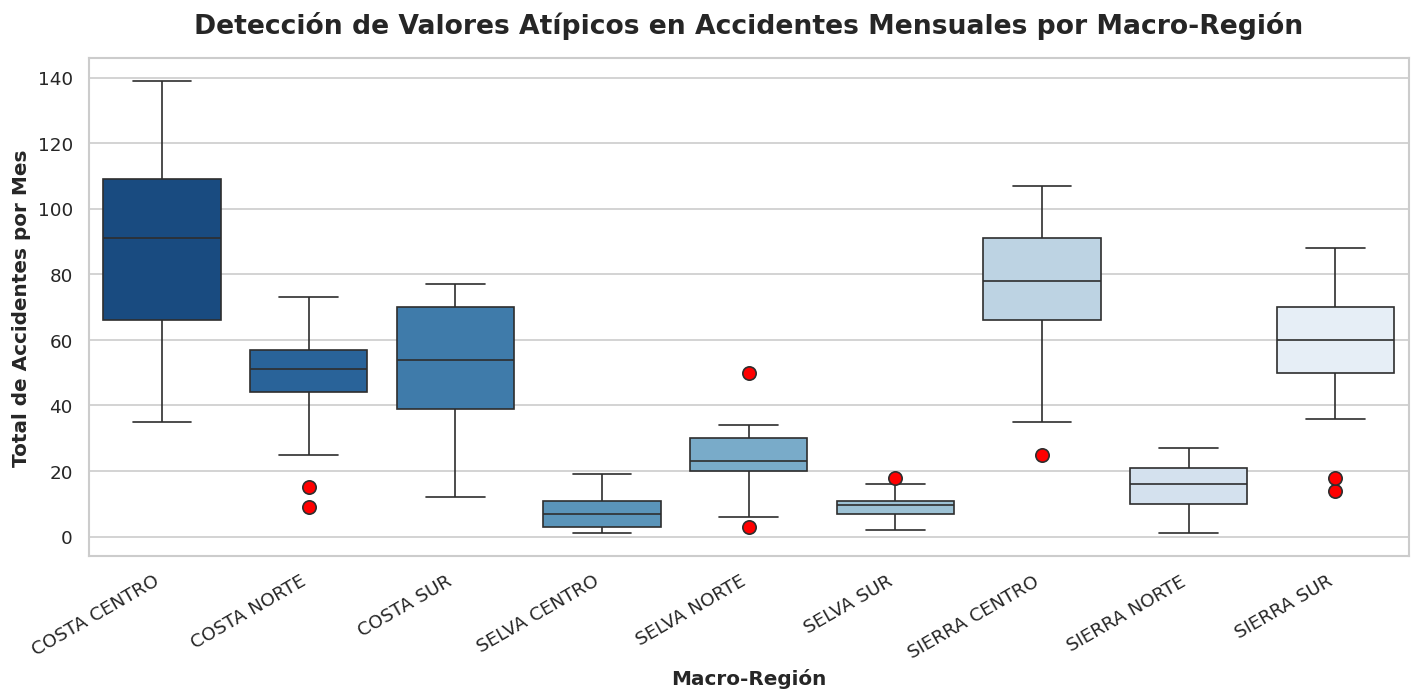

In [59]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Dibujamos el boxplot apuntando a la tabla validada 'acci_mensuales'
ax = sns.boxplot(
    x='MACRO_REGION',
    y='TOTAL_ACCIDENTES',
    data=acci_mensuales,
    palette="Blues_r",
    fliersize=8,
    flierprops={"markerfacecolor": "red", "marker": "o"}
)

# 4) Personalizar títulos y etiquetas
plt.title('Detección de Valores Atípicos en Accidentes Mensuales por Macro-Región', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Macro-Región', fontsize=12, fontweight='bold')
plt.ylabel('Total de Accidentes por Mes', fontsize=12, fontweight='bold')
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

* PUNO: Presenta el valor atípico más alto del dataset (cercano a los 47
accidentes en un solo mes), despegándose notablemente de su rango superior habitual que no suele pasar de 40.

* PIURA: Registra un mes atípico con aproximadamente 34 accidentes, superando por mucho su promedio mensual normal (que ronda los 15 accidentes).

* AMAZONAS: Aunque es una región con pocos accidentes en promedio (menos de 10 al mes), registró un mes atípico que alcanzó los 20 accidentes.

* MADRE DE DIOS: Tiene un mes atípico aislado con cerca de 18 accidentes.

* HUANCAVELICA: Presenta un mes atípico leve con aproximadamente 13 accidentes.

* LAMBAYEQUE: Es un caso muy interesante porque presenta dos tipos de valores atípicos:

* Un mes atípico por exceso (un punto rojo superior, cerca de los 26 accidentes).

* Dos meses atípicos por defecto o escasez (los dos puntos rojos que están abajo, pegados al cero). Esto significa que hubo meses donde prácticamente no se reportaron accidentes, lo cual también es una anomalía en sus datos históricos.

## ¿CUALES SON LAS MODALIDADES DE ACCIDENTE MAS FRECUENTES?

### TABLA DE MODALIDADES DE ACCIDENTE MAS FRECUENTE

In [60]:
mod_stats = df.groupby('MODALIDAD').agg(
    Accidentes=('MODALIDAD', 'count'),
    Fallecidos=('FALLECIDOS', 'sum'),
    Heridos=('HERIDOS', 'sum')
).sort_values('Accidentes', ascending=False)
mod_stats['% Accidentes'] = (mod_stats['Accidentes'] / len(df) * 100).round(1)
display(mod_stats)

,Accidentes,Fallecidos,Heridos,% Accidentes
MODALIDAD,,,,
DESPISTE,3733,503.0,4746.0,47.2
CHOQUE,3532,663.0,5159.0,44.6
ATROPELLO,350,155.0,232.0,4.4
ESPECIAL,177,18.0,81.0,2.2
VOLCADURA,125,8.0,121.0,1.6


### GRAFICO DE BARRAS DE LAS MODALIDADES MAS FRECUENTES

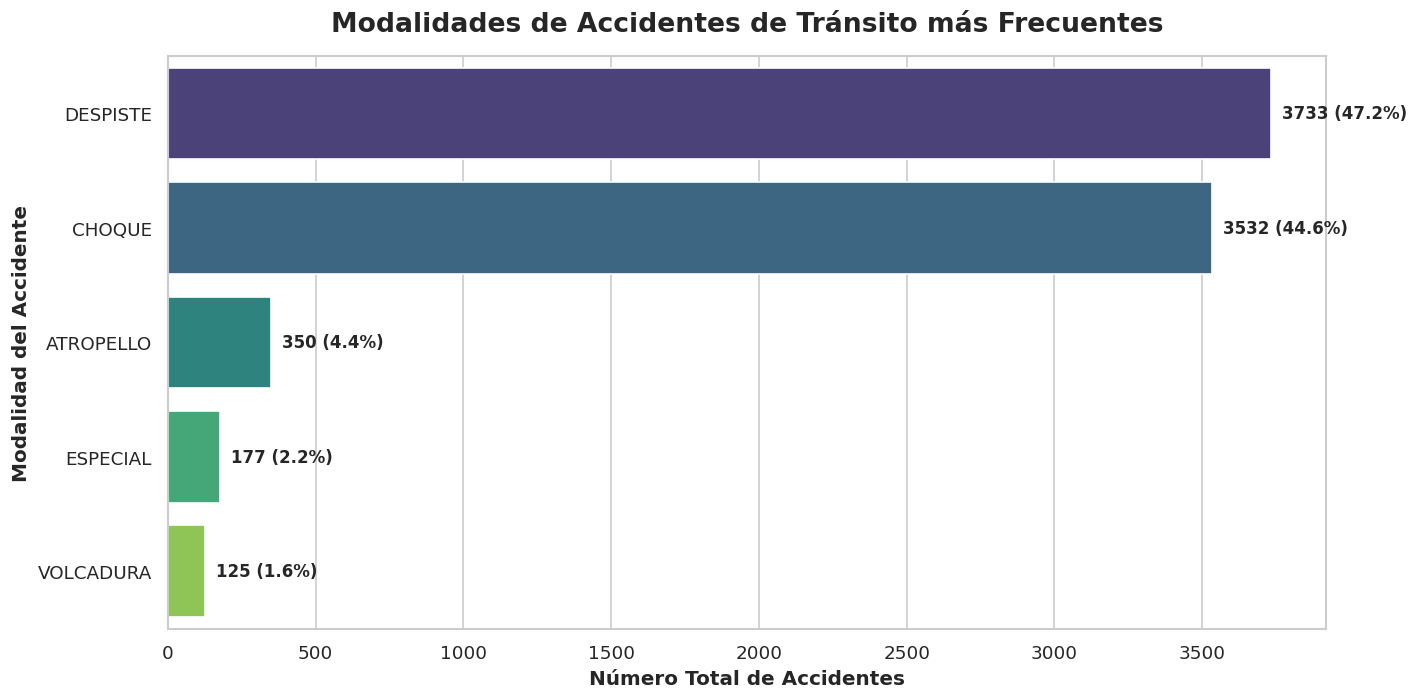

In [61]:
# 1. Calcular la frecuencia de cada modalidad y el porcentaje
conteo_modalidades = df['MODALIDAD'].value_counts().reset_index()
conteo_modalidades.columns = ['MODALIDAD', 'CANTIDAD']
conteo_modalidades['PORCENTAJE'] = (conteo_modalidades['CANTIDAD'] / conteo_modalidades['CANTIDAD'].sum()) * 100

# 2. Configurar el estilo del gráfico
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 3. Crear gráfico de barras horizontales
ax = sns.barplot(
    x='CANTIDAD',
    y='MODALIDAD',
    data=conteo_modalidades,
    palette="viridis" # Degradado de colores profesional
)

# 4. Añadir las etiquetas con la cantidad y porcentaje al final de cada barra
for i, filas in conteo_modalidades.iterrows():
    ax.text(
        filas['CANTIDAD'] + (conteo_modalidades['CANTIDAD'].max() * 0.01), # Posición X
        i,                                                                 # Posición Y
        f"{int(filas['CANTIDAD'])} ({filas['PORCENTAJE']:.1f}%)",          # Texto
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold'
    )

# 5. Personalizar títulos
plt.title('Modalidades de Accidentes de Tránsito más Frecuentes', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Número Total de Accidentes', fontsize=12, fontweight='bold')
plt.ylabel('Modalidad del Accidente', fontsize=12, fontweight='bold')

# Ajustar diseño para que no se corten los textos
plt.tight_layout()
plt.show()

La Modalidad Principal: Identifica la barra más larga (por lo general, en bases de datos de tránsito suelen ser "Choque", "Atropello" o "Despiste"). Redacta indicando que esta modalidad concentra el mayor porcentaje de casos.

El "Principio de Pareto" (80/20): Suma los porcentajes de las 2 o 3 primeras modalidades. Si suman más del 70% o 80%, puedes poner en tu informe: “Las modalidades X, Y y Z representan la gran mayoría de los incidentes viales, sumando el X% del total del dataset”.

Modalidades Marginales: Menciona brevemente cuáles son las barras más cortas (como "Caída de pasajero" o "Volcamiento"), indicando que ocurren con mucha menor frecuencia.

## ¿Qué departamentos concentran más fallecidos?

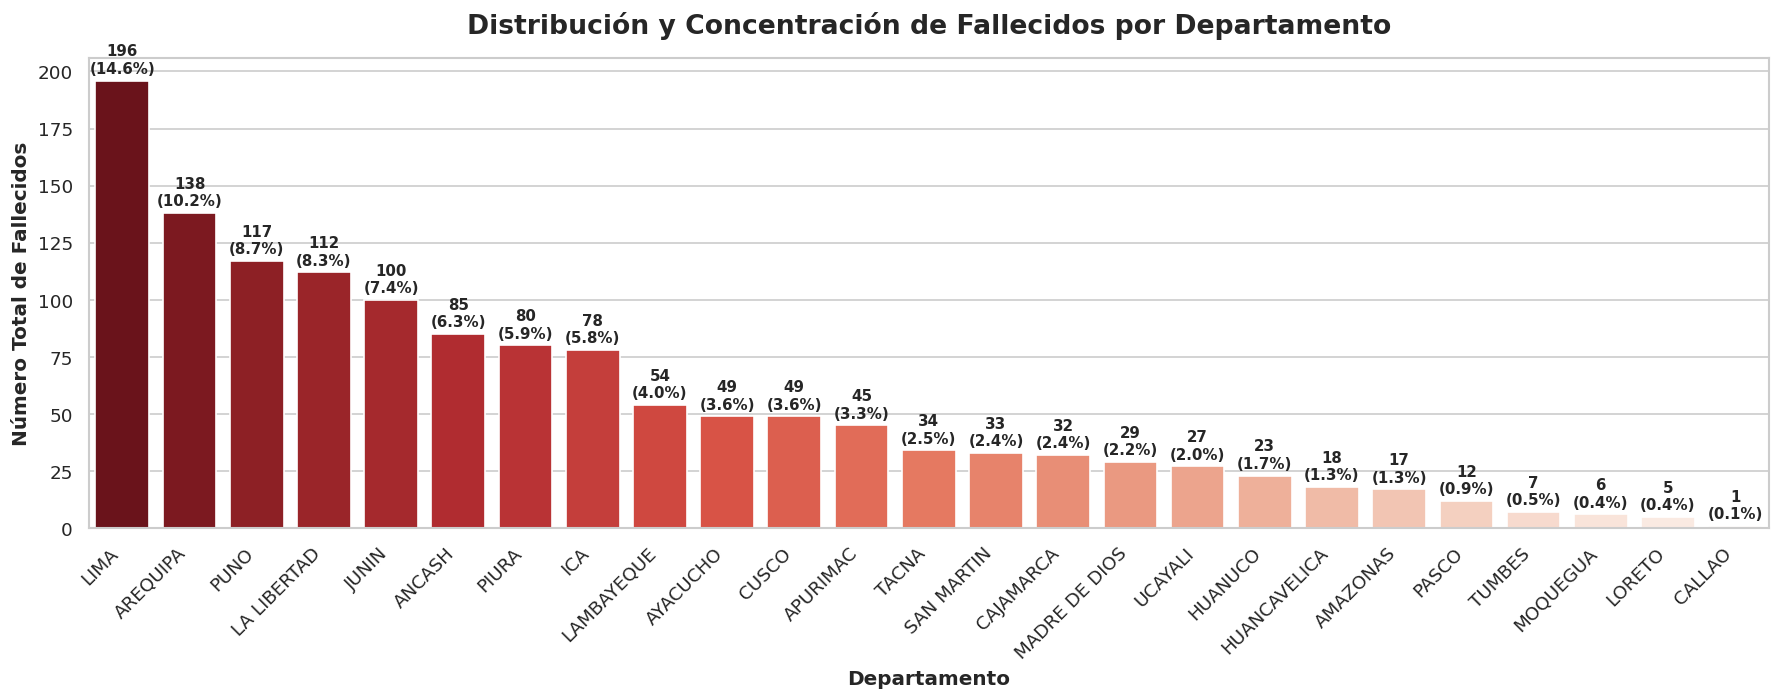

DATOS GLOBALES:
• Total de fallecidos registrados a nivel nacional: 1347
• El departamento líder concentra el 14.6% de las fatalidades.


In [62]:
# 1. Agrupar por departamento y sumar el total de fallecidos, ordenando de mayor a menor
fallecidos_dep = df.groupby('DEPARTAMENTO')['FALLECIDOS'].sum().reset_index()
fallecidos_dep = fallecidos_dep.sort_values(by='FALLECIDOS', ascending=False)

# Calcular el porcentaje de participación de cada departamento sobre el total nacional
total_fallecidos_nacional = fallecidos_dep['FALLECIDOS'].sum()
fallecidos_dep['PORCENTAJE'] = (fallecidos_dep['FALLECIDOS'] / total_fallecidos_nacional) * 100

# 2. Configurar el tamaño del gráfico
plt.figure(figsize=(15, 6))
sns.set_theme(style="whitegrid")

# 3. Crear el gráfico de barras utilizando una paleta de rojos/naranjas (Reds_r)
ax = sns.barplot(
    x='DEPARTAMENTO',
    y='FALLECIDOS',
    data=fallecidos_dep,
    palette="Reds_r"
)

# 4. Añadir las etiquetas con la cantidad exacta sobre cada barra
for p in ax.patches:
    altura = p.get_height()
    if altura > 0: # Solo poner texto si es mayor a cero
        # Calcular el porcentaje correspondiente a esta barra buscando su índice
        porcentaje = (altura / total_fallecidos_nacional) * 100
        ax.text(
            p.get_x() + p.get_width() / 2.,              # Posición X (centro de la barra)
            altura + (fallecidos_dep['FALLECIDOS'].max() * 0.01), # Posición Y (un poco arriba de la barra)
            f'{int(altura)}\n({porcentaje:.1f}%)',        # Texto: Cantidad y Porcentaje
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight='bold'
        )

# 5. Personalizar títulos y ejes
plt.title('Distribución y Concentración de Fallecidos por Departamento', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Departamento', fontsize=12, fontweight='bold')
plt.ylabel('Número Total de Fallecidos', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right') # Rotar nombres para evitar que se amontonen

# Mostrar el gráfico de manera limpia
plt.tight_layout()
plt.show()

# 6. Mostrar un breve resumen de texto informativo abajo del gráfico
print(f"DATOS GLOBALES:")
print(f"• Total de fallecidos registrados a nivel nacional: {int(total_fallecidos_nacional)}")
print(f"• El departamento líder concentra el {fallecidos_dep.iloc[0]['PORCENTAJE']:.1f}% de las fatalidades.")

## ¿Existen diferencias importantes entre departamentos respecto a la gravedad de los accidentes?

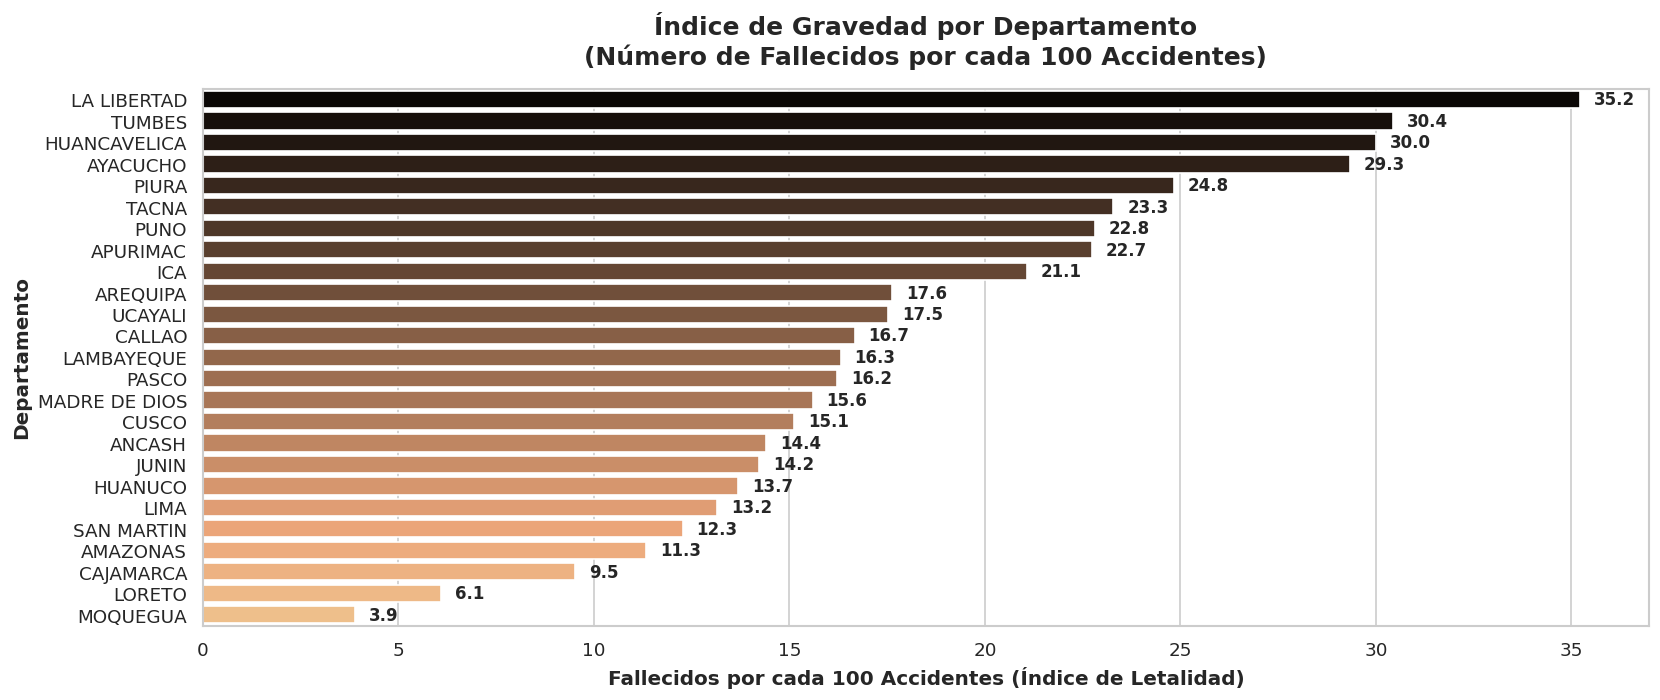

In [63]:
# 1. Calcular el total de accidentes y el total de fallecidos por departamento
gravedad_df = df.groupby('DEPARTAMENTO').agg(
    TOTAL_ACCIDENTES=('DEPARTAMENTO', 'count'),
    TOTAL_FALLECIDOS=('FALLECIDOS', 'sum')
).reset_index()

# 2. Calcular el Índice de Gravedad (Fallecidos promedio por cada 100 accidentes)
gravedad_df['INDICE_GRAVEDAD'] = (gravedad_df['TOTAL_FALLECIDOS'] / gravedad_df['TOTAL_ACCIDENTES']) * 100
gravedad_df = gravedad_df.sort_values(by='INDICE_GRAVEDAD', ascending=False)

# 3. Configurar el estilo del gráfico
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# 4. Crear gráfico de barras horizontales para el índice de gravedad
ax = sns.barplot(
    x='INDICE_GRAVEDAD',
    y='DEPARTAMENTO',
    data=gravedad_df,
    palette="copper" # Paleta elegante que resalta la gravedad
)

# 5. Añadir el valor del índice al final de cada barra
for i, filas in gravedad_df.iterrows():
    # Buscamos la posición real en el dataframe ordenado
    idx_pos = gravedad_df.index.get_loc(i)
    ax.text(
        filas['INDICE_GRAVEDAD'] + (gravedad_df['INDICE_GRAVEDAD'].max() * 0.01), # Posición X
        idx_pos,                                                                 # Posición Y
        f"{filas['INDICE_GRAVEDAD']:.1f}",                                       # Texto (1 decimal)
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold'
    )

# 6. Personalizar títulos
plt.title('Índice de Gravedad por Departamento\n(Número de Fallecidos por cada 100 Accidentes)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Fallecidos por cada 100 Accidentes (Índice de Letalidad)', fontsize=12, fontweight='bold')
plt.ylabel('Departamento', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## ¿Cuál es la probabilidad de que LIMA registre un número de accidentes superior a su promedio mensual esperado, utilizando la distribución de Poisson?

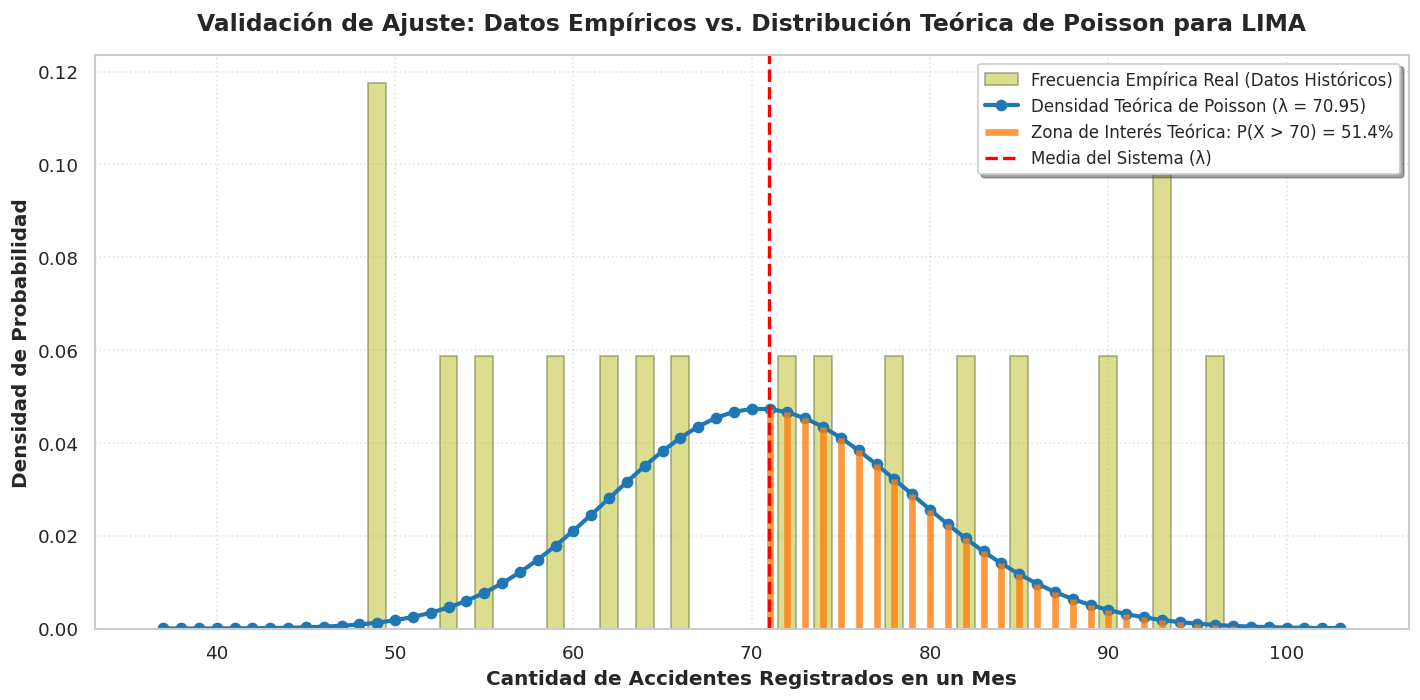

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# 1. Agrupar datos para obtener el conteo mensual histórico
accidentes = df.groupby(['DEPARTAMENTO', 'AÑO', 'MES']).size().reset_index(name='CONTEO')

# 2. Filtrar los datos de LIMA y extraer su vector de datos reales
datos_lima = accidentes[accidentes['DEPARTAMENTO'] == 'LIMA']['CONTEO'].values
lam = datos_lima.mean()  # El estimador de máxima verosimilitud para Lambda

# 3. Rango para la curva teórica de Poisson
k_min = max(0, int(lam - 4 * np.sqrt(lam)))
k_max = int(lam + 4 * np.sqrt(lam))
x_teorico = np.arange(k_min, k_max)
y_teorico = poisson.pmf(x_teorico, lam)

# 4. Calcular el umbral y la probabilidad exacta pedida en el negocio: P(X > λ)
k_umbral = int(np.floor(lam))
prob_poisson_superior = (1 - poisson.cdf(k_umbral, lam)) * 100

# ========================================================
# REFRESCAMIENTO VISUAL ESTADÍSTICO
# ========================================================
plt.figure(figsize=(12, 6))

# A. Datos Reales: Histograma de frecuencias relativas (densidad empírica)
# Usamos bins alineados a los enteros para representar correctamente los conteos discretos
plt.hist(datos_lima, bins=np.arange(k_min, k_max + 1) - 0.5, density=True,
         color='#bcbd22', alpha=0.5, edgecolor='darkolivegreen',
         label='Frecuencia Empírica Real (Datos Históricos)')

# B. Modelo Teórico: Gráfico de líneas y puntos de la PMF de Poisson
plt.plot(x_teorico, y_teorico, 'o-', color='#1f77b4', linewidth=2.5, markersize=6,
         label=f'Densidad Teórica de Poisson (λ = {lam:.2f})')

# C. Área de Interés: Pintar la zona de la curva teórica donde X > promedio
x_naranja = x_teorico[x_teorico > k_umbral]
y_naranja = y_teorico[x_teorico > k_umbral]
plt.vlines(x_naranja, 0, y_naranja, colors='#ff7f0e', alpha=0.8, linewidth=4,
           label=f'Zona de Interés Teórica: P(X > {k_umbral}) = {prob_poisson_superior:.1f}%')

# D. Línea de control del Promedio Esperado
plt.axvline(lam, color='red', linestyle='--', linewidth=2,
            label=f'Media del Sistema (λ)')

# Detalles formales y estéticos
plt.title("Validación de Ajuste: Datos Empíricos vs. Distribución Teórica de Poisson para LIMA",
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Cantidad de Accidentes Registrados en un Mes", fontsize=12, fontweight='bold')
plt.ylabel("Densidad de Probabilidad", fontsize=12, fontweight='bold')

# Ubicación de la leyenda fuera de las barras para máxima limpieza
plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=10)
plt.grid(axis='both', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

## ¿Los accidentes se distribuyen de manera uniforme entre los departamentos o se concentran en algunos pocos?

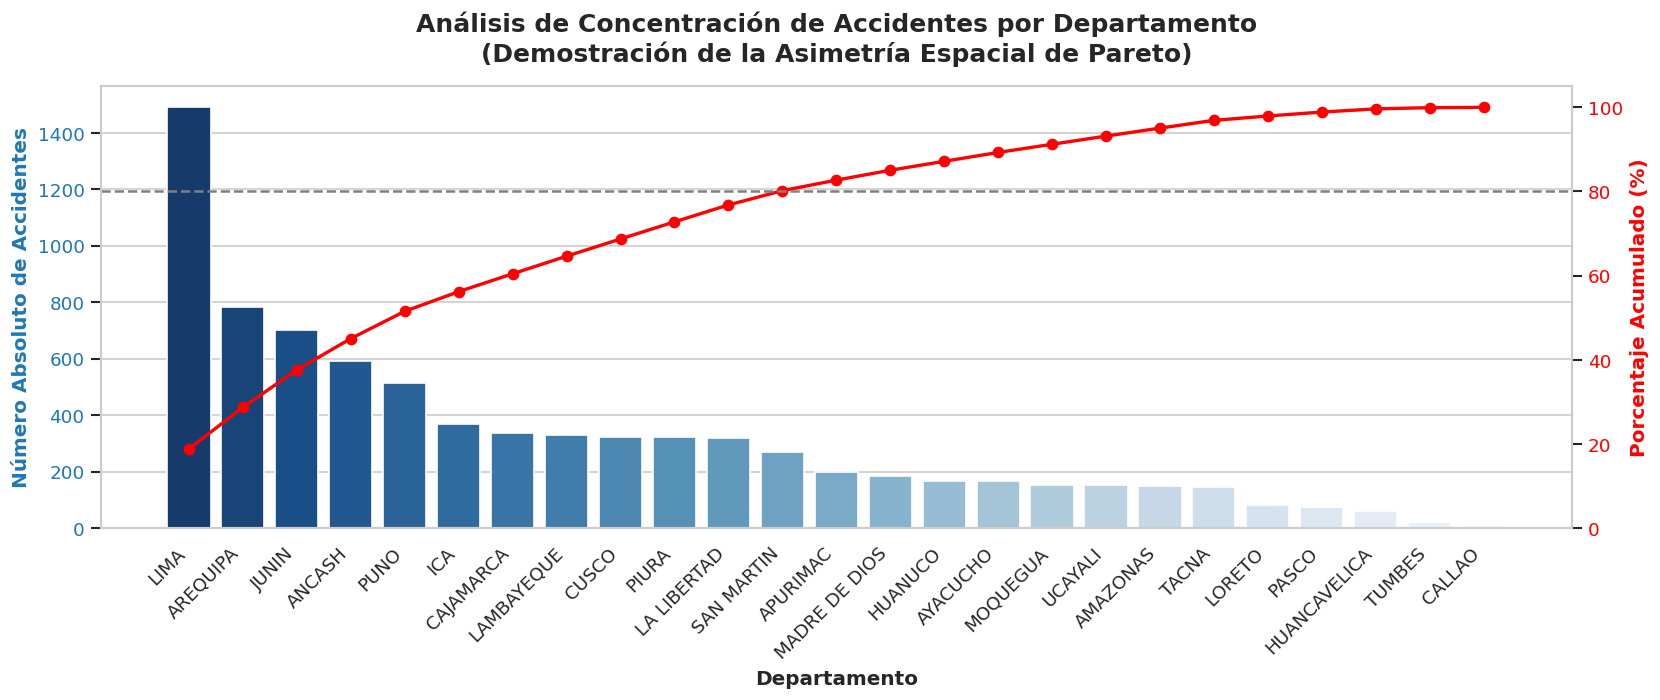


• Total de accidentes evaluados a nivel nacional: 7917
• El departamento líder concentra el 18.8% de la accidentalidad.


In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular la frecuencia absoluta de accidentes por departamento
conteo_dep = df['DEPARTAMENTO'].value_counts().reset_index()
conteo_dep.columns = ['DEPARTAMENTO', 'CANTIDAD']

# 2. Calcular el porcentaje individual y el porcentaje acumulado (CDF)
total_accidentes = conteo_dep['CANTIDAD'].sum()
conteo_dep['PORCENTAJE'] = (conteo_dep['CANTIDAD'] / total_accidentes) * 100
conteo_dep['PORCENTAJE_ACUM'] = conteo_dep['PORCENTAJE'].cumsum()

# ========================================================
# CONSTRUCCIÓN DEL GRÁFICO DE DOBLE EJE (PARETO)
# ========================================================
fig, ax1 = plt.subplots(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# Eje primario (Izquierdo): Barras para el conteo de accidentes
ax1 = sns.barplot(
    x='DEPARTAMENTO',
    y='CANTIDAD',
    data=conteo_dep,
    palette="Blues_r",
    ax=ax1
)
ax1.set_xlabel('Departamento', fontsize=12, fontweight='bold')
ax1.set_ylabel('Número Absoluto de Accidentes', fontsize=12, fontweight='bold', color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_xticklabels(conteo_dep['DEPARTAMENTO'], rotation=45, ha='right')

# Eje secundario (Derecho): Línea para el porcentaje acumulado
ax2 = ax1.twinx()
ax2.plot(
    conteo_dep['DEPARTAMENTO'],
    conteo_dep['PORCENTAJE_ACUM'],
    color='red',
    marker='o',
    linewidth=2,
    label='% Acumulado'
)
ax2.set_ylabel('Porcentaje Acumulado (%)', fontsize=12, fontweight='bold', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 105)

# Línea de control de Pareto al 80%
ax2.axhline(80, color='gray', linestyle='--', linewidth=1.5)

# Personalización formal
plt.title('Análisis de Concentración de Accidentes por Departamento\n(Demostración de la Asimetría Espacial de Pareto)', fontsize=15, fontweight='bold', pad=15)
plt.grid(False) # Evitar cuadrículas superpuestas de ambos ejes

fig.tight_layout()
plt.show()

# Mostrar métricas clave en la terminal
print(f"\n• Total de accidentes evaluados a nivel nacional: {total_accidentes}")
print(f"• El departamento líder concentra el {conteo_dep.iloc[0]['PORCENTAJE']:.1f}% de la accidentalidad.")

## ¿Qué modalidades tienen mayor dispersión en el número de víctimas?

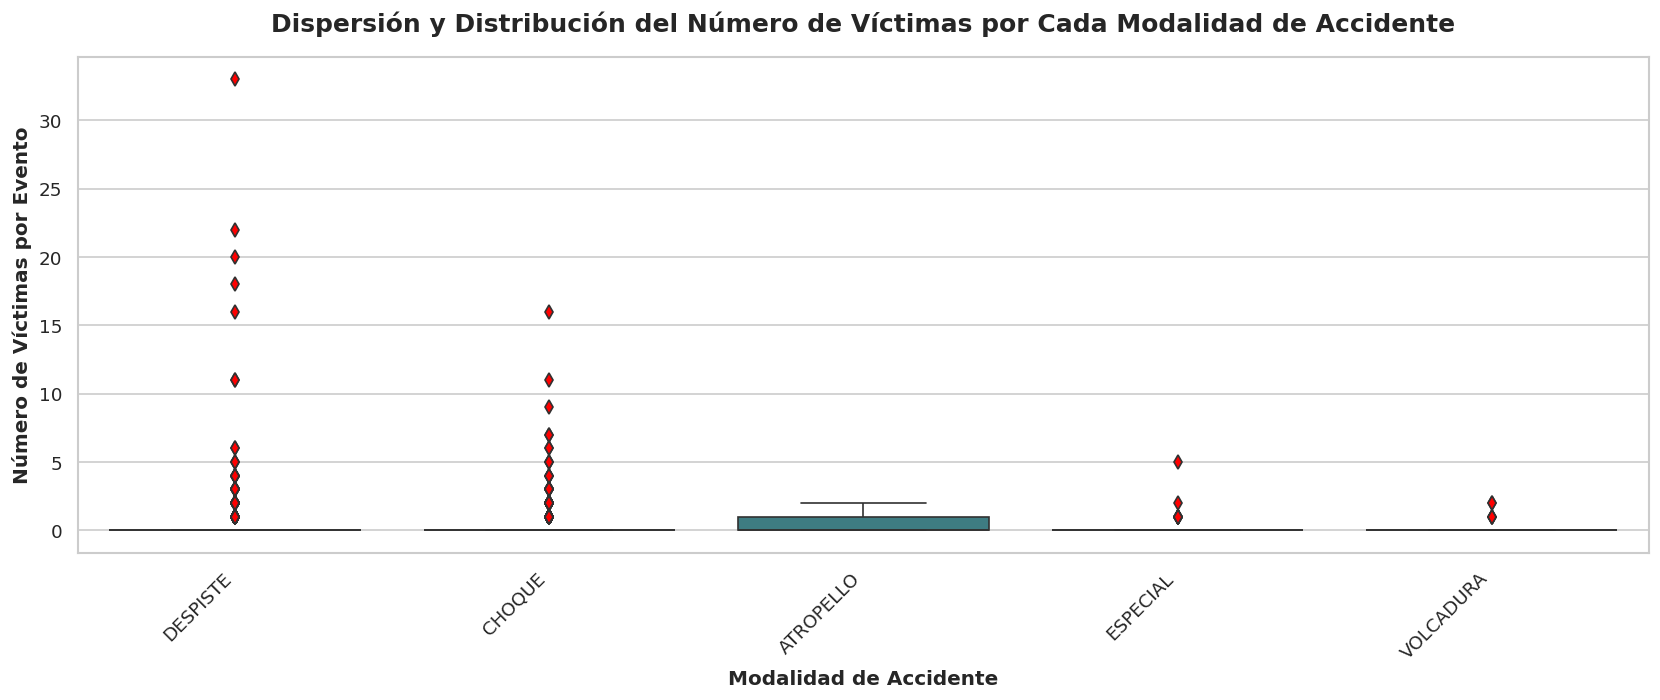

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular métricas de dispersión por modalidad
# Asumimos que la columna se llama 'FALLECIDOS'. Si mide heridos+fallecidos, ajusta el nombre.
dispersion_modalidad = df.groupby('MODALIDAD')['FALLECIDOS'].agg(
    Media='mean',
    Desviacion_Estandar='std',
    Varianza='var',
    Minimo='min',
    Maximo='max',
    Conteo='count'
).reset_index()

# Calcular el Coeficiente de Variación (CV) para medir la dispersión relativa
dispersion_modalidad['Coef_Variacion'] = dispersion_modalidad['Desviacion_Estandar'] / dispersion_modalidad['Media']
dispersion_modalidad = dispersion_modalidad.sort_values(by='Desviacion_Estandar', ascending=False)

# ========================================================
# VISUALIZACIÓN 1: BOXPLOT PARA OBSERVAR LA DISPERSIÓN TOTAL
# ========================================================
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# Ordenamos el boxplot según las modalidades con mayor desviación estándar
orden_modalidades = dispersion_modalidad['MODALIDAD'].tolist()

ax = sns.boxplot(
    x='MODALIDAD',
    y='FALLECIDOS',
    data=df,
    order=orden_modalidades,
    palette="crest",
    fliersize=6,
    flierprops={"markerfacecolor": "red", "marker": "d"} # Outliers en forma de diamante rojo
)

plt.title('Dispersión y Distribución del Número de Víctimas por Cada Modalidad de Accidente', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Modalidad de Accidente', fontsize=12, fontweight='bold')
plt.ylabel('Número de Víctimas por Evento', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

TABLA DE DISPERSION POR MODALIDAD

In [67]:
dispersion_modalidad[['MODALIDAD', 'Media', 'Desviacion_Estandar', 'Coef_Variacion', 'Maximo']]

,MODALIDAD,Media,Desviacion_Estandar,Coef_Variacion,Maximo
2,DESPISTE,0.134744,0.963874,7.153361,33.0
1,CHOQUE,0.187712,0.638283,3.400324,16.0
0,ATROPELLO,0.442857,0.519966,1.174116,2.0
3,ESPECIAL,0.101695,0.465695,4.579337,5.0
4,VOLCADURA,0.064000,0.304377,4.755886,2.0


## MAPA DE CALOR

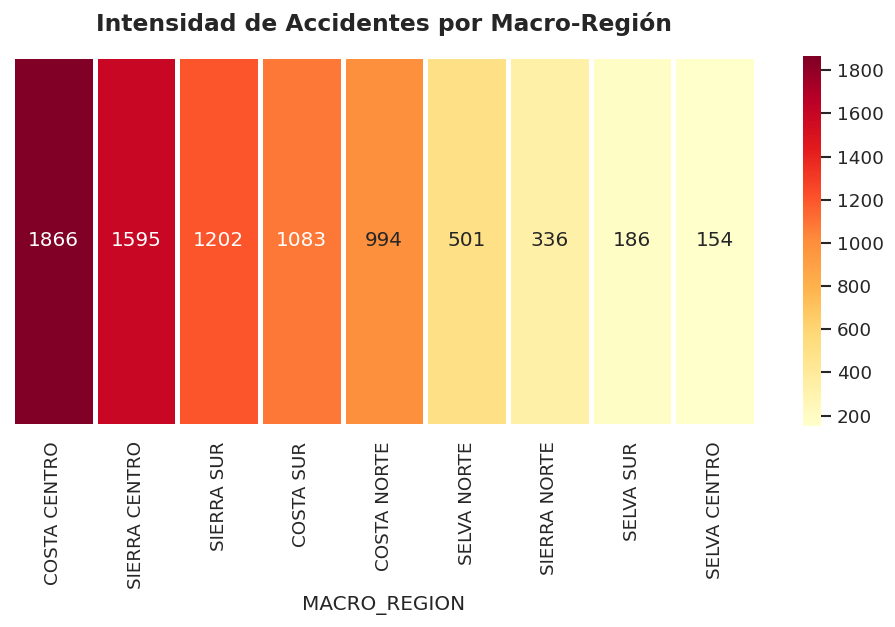

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

# Agrupamos por macroregión para obtener la métrica
resumen_macro = df.groupby('MACRO_REGION').size().reset_index(name='TOTAL_ACCIDENTES')
resumen_macro = resumen_macro.sort_values(by='TOTAL_ACCIDENTES', ascending=False)

# Creamos una representación matricial para simular el peso regional
plt.figure(figsize=(10, 4))
sns.heatmap(
    resumen_macro.set_index('MACRO_REGION').T,
    cmap="YlOrRd",
    annot=True,
    fmt="d",
    cbar=True,
    linewidths=2
)
plt.title("Intensidad de Accidentes por Macro-Región", fontsize=14, fontweight='bold', pad=15)
plt.yticks([]) # Ocultar el eje Y de la matriz
plt.show()

In [69]:
import pandas as pd
import folium
from folium import PolyLine, LayerControl
from folium.plugins import AntPath

# 1. Dataset Real
datos_vias = {
    'CODIGO_VIA': [
        'PE-1N', 'PE-1S', 'PE-3S', 'PE-22', 'PE-3N', 'PE-5N', 'PE-34A', 'PE-30A',
        'PE-30C', 'PE-1NJ', 'PE-1SD', 'PE-18C', 'PE-28B', 'PE-08B', 'PE-08', 'PE-16'
    ],
    'ACCIDENTES': [1432, 1386, 633, 534, 465, 431, 358, 196, 194, 140, 116, 115, 108, 92, 92, 87]
}
df_vias = pd.DataFrame(datos_vias)

# 2. Vectores Geográficos de las Carreteras
coordenadas_vias = {
    'PE-1N': [[-12.0464, -77.0428], [-11.1064, -77.6122], [-9.1136, -78.5136], [-8.1116, -79.0286], [-6.7722, -79.8381], [-5.1944, -80.6319], [-3.5656, -80.4517]],
    'PE-1S': [[-12.0464, -77.0428], [-13.0781, -76.3833], [-14.0678, -75.7286], [-15.4411, -74.7831], [-16.4090, -71.5375], [-17.1939, -70.9356], [-18.0142, -70.2512]],
    'PE-22': [[-12.0464, -77.0428], [-11.9350, -76.7022], [-11.8394, -76.3814], [-11.7516, -76.1950], [-11.5958, -75.8906]],
    'PE-3S': [[-11.5958, -75.8906], [-12.0651, -75.2048], [-13.1588, -74.2239], [-13.6339, -72.8814], [-13.5183, -71.9775], [-15.4925, -70.1269], [-15.8402, -70.0219]],
    'PE-3N': [[-11.5958, -75.8906], [-10.6678, -76.2561], [-9.9306, -76.2406], [-8.1256, -77.2831], [-7.1539, -78.5183], [-6.2319, -79.2156]],
    'PE-5N': [[-11.1333, -75.3333], [-8.9222, -76.0147], [-6.4894, -76.3725], [-5.6947, -78.5136]],
    'PE-34A': [[-16.4090, -71.5375], [-15.7161, -71.0556], [-15.4925, -70.1269]],
    'PE-30A': [[-14.0678, -75.7286], [-14.2953, -72.9531], [-13.6339, -72.8814]],
    'PE-08': [[-7.1539, -78.5183], [-7.3822, -79.5856]],
    'PE-16': [[-11.1064, -77.6122], [-10.2625, -77.5292]],
}

# 3. Lógica Teatral de Colores y Velocidad de Animación
def configurar_riesgo(accidentes):
    if accidentes > 1000:
        return {'color': '#e74c3c', 'pulse_color': '#ffffff', 'dash_array': [10, 20], 'delay': 600} # Extremo (Rojo a mil por hora)
    elif accidentes > 500:
        return {'color': '#e67e22', 'pulse_color': '#ffffff', 'dash_array': [15, 30], 'delay': 1000} # Alto (Naranja)
    elif accidentes > 150:
        return {'color': '#f1c40f', 'pulse_color': '#2c3e50', 'dash_array': [20, 40], 'delay': 1500} # Medio (Amarillo)
    else:
        return {'color': '#2ecc71', 'pulse_color': '#ffffff', 'dash_array': [20, 40], 'delay': 2000} # Bajo (Verde)

# 4. Inicializar Mapa con múltiples capas de fondo (Mesa de Control)
mapa_pro = folium.Map(location=[-9.1900, -75.0152], zoom_start=6, tiles=None)

# Añadimos los azulejos (Tiles) que el usuario podrá alternar
folium.TileLayer('OpenStreetMap', name='Mapa de Calles Físicas').add_to(mapa_pro)

# 5. Inyectar las carreteras animadas (AntPath)
for _, fila in df_vias.iterrows():
    codigo = fila['CODIGO_VIA']
    accidentes = fila['ACCIDENTES']

    if codigo in coordenadas_vias:
        cfg = configurar_riesgo(accidentes)
        grosor = 6 if accidentes > 1000 else 4

        # El plugin AntPath crea la animación lineal vectorizada
        AntPath(
            locations=coordenadas_vias[codigo],
            color=cfg['color'],
            pulse_color=cfg['pulse_color'],
            weight=grosor,
            opacity=0.85,
            dash_array=cfg['dash_array'],
            delay=cfg['delay'],
            tooltip=f"<div style='font-family: Arial; font-size: 12px;'><b>Carretera:</b> {codigo}<br><b>Siniestros:</b> {accidentes}</div>"
        ).add_to(mapa_pro)

# 6. Añadir una Leyenda Ejecutiva Flotante (Dashboard Style) usando HTML/CSS
html_leyenda = '''
<div style="
    position: fixed;
    bottom: 30px; left: 30px; width: 230px; height: 160px;
    background-color: rgba(255, 255, 255, 0.9);
    z-index:9999; font-size:13px; font-family: 'Arial', sans-serif;
    border: 2px solid #ccc; border-radius: 8px; padding: 10px;
    box-shadow: 2px 2px 5px rgba(0,0,0,0.2);
">
    <b style="font-size: 14px; color: #2c3e50;">Peligrosidad Vial</b><br>
    <p style="margin: 6px 0;"><i style="background:#e74c3c; width:25px; height:10px; display:inline-block; border-radius:3px; margin-right:5px;"></i> Crítico (&gt;1000)</p>
    <p style="margin: 6px 0;"><i style="background:#e67e22; width:25px; height:10px; display:inline-block; border-radius:3px; margin-right:5px;"></i> Alto (500 - 1000)</p>
    <p style="margin: 6px 0;"><i style="background:#f1c40f; width:25px; height:10px; display:inline-block; border-radius:3px; margin-right:5px;"></i> Moderado (150 - 500)</p>
    <p style="margin: 6px 0;"><i style="background:#2ecc71; width:25px; height:10px; display:inline-block; border-radius:3px; margin-right:5px;"></i> Bajo (&lt;150)</p>
</div>
'''
mapa_pro.get_root().html.add_child(folium.Element(html_leyenda))

# Añadir el botón selector de capas en la esquina superior derecha
LayerControl(position='topright').add_to(mapa_pro)

# Guardar y mostrar
mapa_pro.save("sistema_vial_premium.html")
mapa_pro

## CONCLUCIONES

## 3. Prueba 1 — Modalidad × Gravedad (Chi-cuadrado de independencia)

**Qué se prueba:** si la gravedad del accidente (Sin víctimas / Con heridos / Fatal) es independiente de la modalidad, o si existe asociación entre ambas variables categóricas.

- H0: la gravedad es independiente de la modalidad.
- H1: la gravedad depende de la modalidad.

In [70]:
df['PICO'] = df['HORA_NUM'].apply(lambda h: 1 if (pd.notna(h) and ((6 <= h <= 9) or (16 <= h <= 19))) else 0)

In [71]:
tabla_mg = pd.crosstab(df['MODALIDAD'], df['GRAVEDAD'])
chi2, p_valor, gl, esperados = stats.chi2_contingency(tabla_mg)

n = tabla_mg.sum().sum()
cramer_v = np.sqrt(chi2 / (n * (min(tabla_mg.shape) - 1)))

print("Tabla de contingencia observada:")
display(tabla_mg)
print(f"\nChi2 = {chi2:.2f} | gl = {gl} | p-valor = {p_valor:.2e}")
print(f"V de Cramér = {cramer_v:.3f}")
print("Conclusión:", "se rechaza H0 (p<0.05): la gravedad depende de la modalidad." if p_valor<0.05 else "no se rechaza H0.")

Tabla de contingencia observada:


GRAVEDAD,Con heridos,Fatal,Sin víctimas
MODALIDAD,,,
ATROPELLO,161,151,38
CHOQUE,2010,484,1038
DESPISTE,1838,273,1622
ESPECIAL,40,13,124
VOLCADURA,51,6,68



Chi2 = 660.76 | gl = 8 | p-valor = 2.00e-137
V de Cramér = 0.204
Conclusión: se rechaza H0 (p<0.05): la gravedad depende de la modalidad.


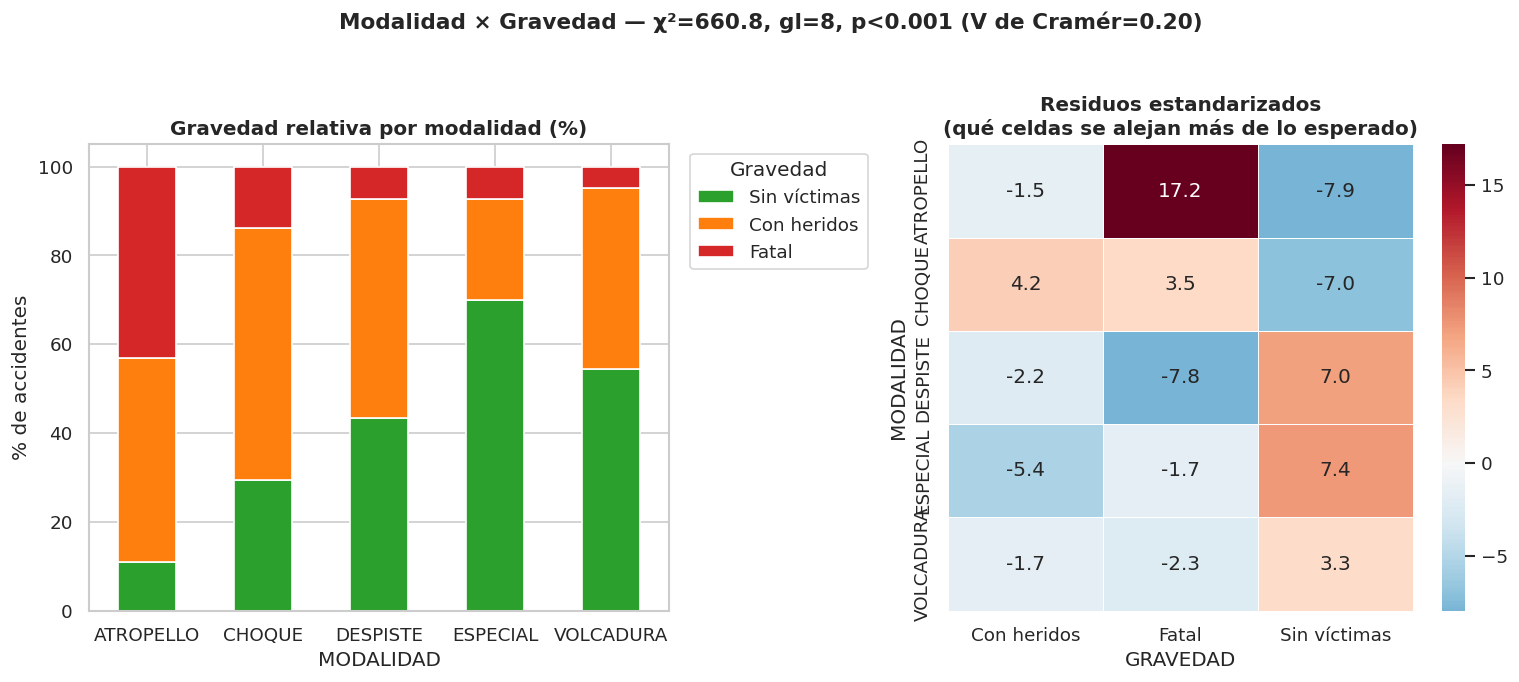

In [72]:
# Visualización: % de gravedad por modalidad + mapa de residuos estandarizados
ct_pct = pd.crosstab(df['MODALIDAD'], df['GRAVEDAD'], normalize='index')*100
esperados_df = pd.DataFrame(esperados, index=tabla_mg.index, columns=tabla_mg.columns)
residuos = (tabla_mg - esperados_df) / np.sqrt(esperados_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
ct_pct[['Sin víctimas','Con heridos','Fatal']].plot(kind='bar', stacked=True, ax=axes[0],
        color=['#2ca02c','#ff7f0e','#d62728'], edgecolor='white')
axes[0].set_title('Gravedad relativa por modalidad (%)', fontweight='bold')
axes[0].set_ylabel('% de accidentes'); axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Gravedad', bbox_to_anchor=(1.02,1), loc='upper left')

sns.heatmap(residuos, annot=True, fmt='.1f', cmap='RdBu_r', center=0, ax=axes[1], linewidths=.5, linecolor='white')
axes[1].set_title('Residuos estandarizados\n(qué celdas se alejan más de lo esperado)', fontweight='bold')

fig.suptitle(f'Modalidad × Gravedad — χ²={chi2:.1f}, gl={gl}, p<0.001 (V de Cramér={cramer_v:.2f})',
             fontweight='bold', fontsize=13, y=1.03)
plt.tight_layout(); plt.show()
# Interpretación: ATROPELLO y VOLCADURA muestran proporciones de casos fatales muy por encima de lo esperado.

## 4. Prueba 2 — Heridos × Modalidad (Kruskal-Wallis)

**Qué se prueba:** si el número de heridos tiene la misma distribución en las 5 modalidades. Se usa Kruskal-Wallis (no paramétrica) porque HERIDOS es una variable de conteo muy asimétrica (no cumple normalidad, requisito de un ANOVA clásico).

- H0: la distribución de HERIDOS es igual entre modalidades.
- H1: al menos una modalidad difiere.

In [73]:
grupos_heridos = [df[df['MODALIDAD'] == m]['HERIDOS'] for m in df['MODALIDAD'].dropna().unique()]
kw_stat, kw_p = stats.kruskal(*grupos_heridos)
print(f"Kruskal-Wallis: H = {kw_stat:.2f} | p-valor = {kw_p:.2e}")
print("Conclusión:", "se rechaza H0 (p<0.05): los heridos varían según la modalidad." if kw_p<0.05 else "no se rechaza H0.")

Kruskal-Wallis: H = 208.96 | p-valor = 4.45e-44
Conclusión: se rechaza H0 (p<0.05): los heridos varían según la modalidad.


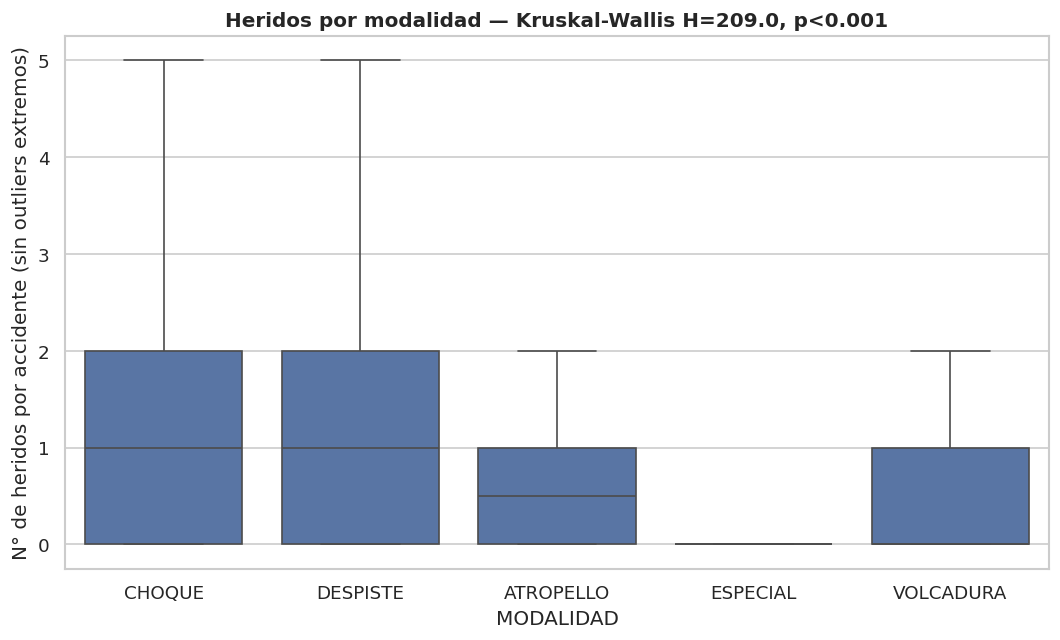

In [74]:
fig, ax = plt.subplots(figsize=(9, 5.5))
orden = df.groupby('MODALIDAD')['HERIDOS'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='MODALIDAD', y='HERIDOS', order=orden, ax=ax, showfliers=False)
ax.set_title(f'Heridos por modalidad — Kruskal-Wallis H={kw_stat:.1f}, p<0.001', fontweight='bold')
ax.set_ylabel('N° de heridos por accidente (sin outliers extremos)')
plt.tight_layout(); plt.show()

## 5. Prueba 3 — Total de víctimas × Departamento, Top 10 (Kruskal-Wallis)

**Qué se prueba:** si la severidad (TOTAL_VICTIMAS = fallecidos + heridos) es igual entre los 10 departamentos con más accidentes, o si algunos son sistemáticamente más severos.

- H0: TOTAL_VICTIMAS tiene la misma distribución en los 10 departamentos.
- H1: al menos un departamento difiere.

In [75]:
top10_dep = df['DEPARTAMENTO'].value_counts().head(10).index
grupos_dep = [df[df['DEPARTAMENTO'] == d]['TOTAL_VICTIMAS'] for d in top10_dep]
kw_stat2, kw_p2 = stats.kruskal(*grupos_dep)
print(f"Kruskal-Wallis: H = {kw_stat2:.2f} | p-valor = {kw_p2:.2e}")
print("Conclusión:", "se rechaza H0 (p<0.05): la severidad difiere entre departamentos." if kw_p2<0.05 else "no se rechaza H0.")

Kruskal-Wallis: H = 80.59 | p-valor = 1.23e-13
Conclusión: se rechaza H0 (p<0.05): la severidad difiere entre departamentos.


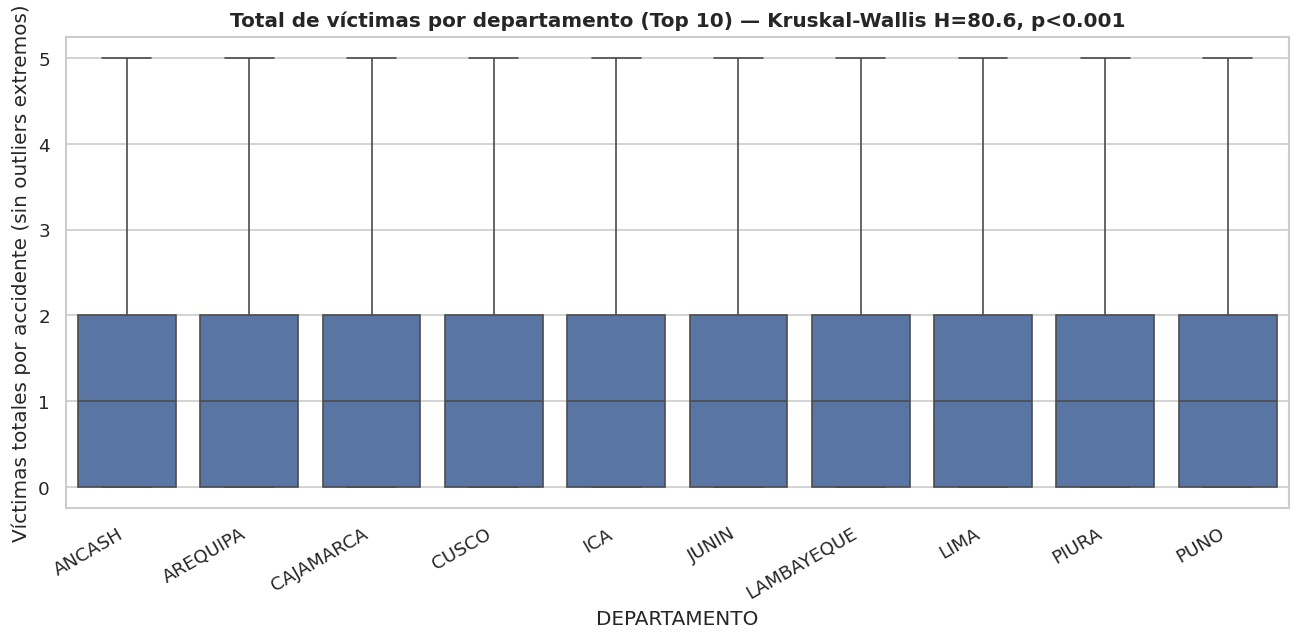

In [76]:
sub = df[df['DEPARTAMENTO'].isin(top10_dep)]
orden2 = sub.groupby('DEPARTAMENTO')['TOTAL_VICTIMAS'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.boxplot(data=sub, x='DEPARTAMENTO', y='TOTAL_VICTIMAS', order=orden2, ax=ax, showfliers=False)
ax.set_title(f'Total de víctimas por departamento (Top 10) — Kruskal-Wallis H={kw_stat2:.1f}, p<0.001', fontweight='bold', fontsize=12)
ax.set_ylabel('Víctimas totales por accidente (sin outliers extremos)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

## 6. Prueba 4 — Franja horaria pico × Accidentes con víctimas (Chi-cuadrado)

**Qué se prueba:** si la proporción de accidentes con al menos una víctima es distinta dentro y fuera de la franja horaria pico (6-9h y 16-19h).

- H0: la proporción de accidentes con víctimas es igual dentro y fuera de la franja pico.
- H1: la proporción difiere.

In [77]:
tabla_pico = pd.crosstab(df['PICO'], df['CON_VICTIMAS'])
chi2_p, p_p, gl_p, exp_p = stats.chi2_contingency(tabla_pico)
print("Tabla PICO (0=fuera de pico, 1=pico) x CON_VICTIMAS:")
display(tabla_pico)
print(f"\nChi2 = {chi2_p:.2f} | p-valor = {p_p:.3f}")
print("Conclusión:", "se rechaza H0." if p_p<0.05 else "NO se rechaza H0 (p>0.05): no hay diferencia significativa.")

Tabla PICO (0=fuera de pico, 1=pico) x CON_VICTIMAS:


CON_VICTIMAS,0,1
PICO,,
0,1687,2884
1,1203,2143



Chi2 = 0.72 | p-valor = 0.397
Conclusión: NO se rechaza H0 (p>0.05): no hay diferencia significativa.


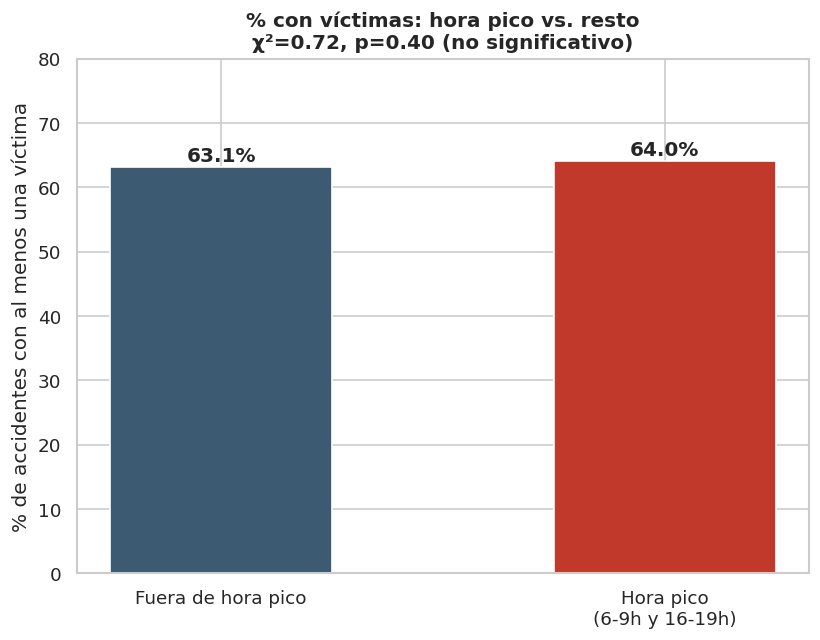

In [78]:
pct = df.groupby('PICO')['CON_VICTIMAS'].mean()*100
fig, ax = plt.subplots(figsize=(7, 5.5))
labels = ['Fuera de hora pico', 'Hora pico\n(6-9h y 16-19h)']
bars = ax.bar(labels, pct.values, color=['#3D5A73','#C0392B'], width=0.5, edgecolor='white')
for b, v in zip(bars, pct.values):
    ax.text(b.get_x()+b.get_width()/2, v+1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_ylim(0, 80)
ax.set_ylabel('% de accidentes con al menos una víctima')
ax.set_title(f'% con víctimas: hora pico vs. resto\nχ²={chi2_p:.2f}, p={p_p:.2f} (no significativo)', fontweight='bold')
plt.tight_layout(); plt.show()
# Interpretación: la hora pico concentra más VOLUMEN de accidentes, pero no más víctimas por accidente.

## 7. Prueba 5 — Kilómetro de la vía × Total de víctimas (Correlación de Spearman)

**Qué se prueba:** si existe una relación monótona entre el kilómetro donde ocurre el accidente y el total de víctimas. Se usa Spearman (no Pearson) porque no se asume que la relación sea lineal.

- H0: no existe correlación monótona entre KILOMETRO y TOTAL_VICTIMAS.
- H1: existe correlación.

In [79]:
sub2 = df.dropna(subset=['KILOMETRO'])
sub2 = sub2[sub2['KILOMETRO'] < sub2['KILOMETRO'].quantile(0.99)]  # se recorta el 1% superior (outliers de km)

rho, p_rho = stats.spearmanr(sub2['KILOMETRO'], sub2['TOTAL_VICTIMAS'])
print(f"Correlación de Spearman: rho = {rho:.4f} | p-valor = {p_rho:.3f}")
print("Conclusión:", "se rechaza H0." if p_rho<0.05 else "no se rechaza H0: la correlación es prácticamente nula.")

Correlación de Spearman: rho = 0.0202 | p-valor = 0.073
Conclusión: no se rechaza H0: la correlación es prácticamente nula.


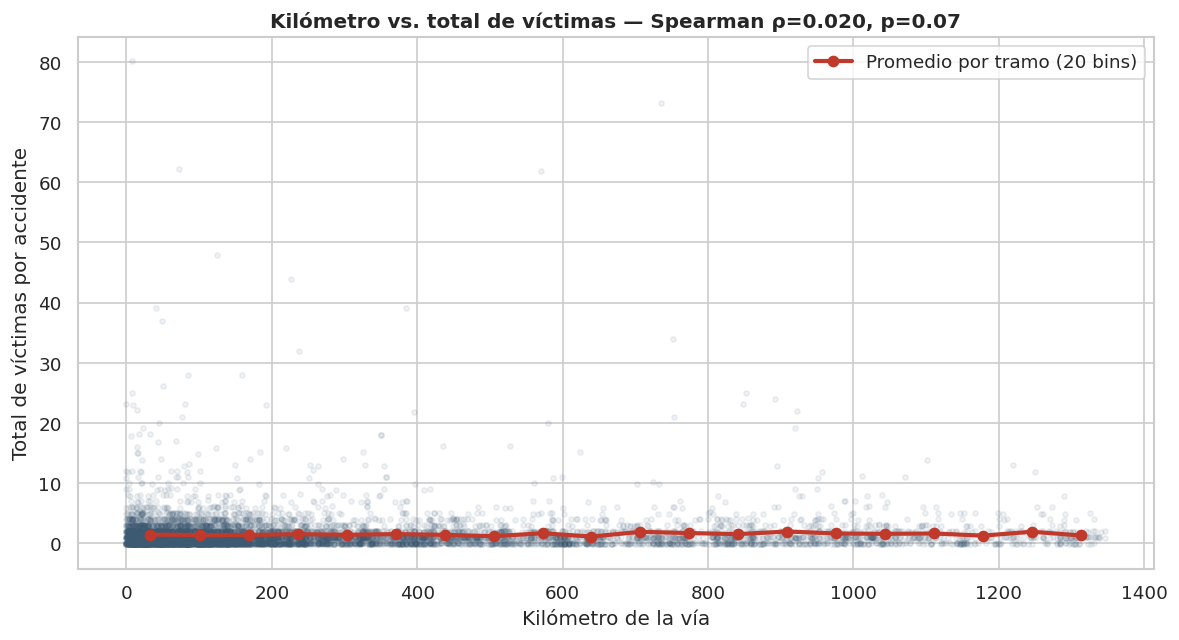

In [80]:
sub2 = sub2.copy()
sub2['KM_BIN'] = pd.cut(sub2['KILOMETRO'], bins=20)
bin_means = sub2.groupby('KM_BIN', observed=True)['TOTAL_VICTIMAS'].mean()
bin_centers = [interval.mid for interval in bin_means.index]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.scatter(sub2['KILOMETRO'], sub2['TOTAL_VICTIMAS'] + np.random.uniform(-0.15, 0.15, len(sub2)),
           alpha=0.08, s=10, color='#3D5A73')
ax.plot(bin_centers, bin_means.values, color='#C0392B', linewidth=2.5, marker='o', label='Promedio por tramo (20 bins)')
ax.set_title(f'Kilómetro vs. total de víctimas — Spearman ρ={rho:.3f}, p={p_rho:.2f}', fontweight='bold', fontsize=12)
ax.set_xlabel('Kilómetro de la vía'); ax.set_ylabel('Total de víctimas por accidente')
ax.legend()
plt.tight_layout(); plt.show()

## 8. Prueba 6 — Modalidad × Año, 2020 vs. 2021 (Chi-cuadrado)

**Qué se prueba:** si la composición de modalidades de accidente cambió entre 2020 y 2021.

- H0: la proporción de modalidades es igual en 2020 y 2021.
- H1: la proporción difiere entre años.

In [81]:
tabla_anio = pd.crosstab(df['MODALIDAD'], df['AÑO'])
chi2_a, p_a, gl_a, exp_a = stats.chi2_contingency(tabla_anio)
display(tabla_anio)
print(f"\nChi2 = {chi2_a:.2f} | gl = {gl_a} | p-valor = {p_a:.2e}")
print("Conclusión:", "se rechaza H0 (p<0.05): la composición cambió entre años." if p_a<0.05 else "no se rechaza H0.")

AÑO,2020,2021
MODALIDAD,,
ATROPELLO,194,156
CHOQUE,1629,1903
DESPISTE,1920,1813
ESPECIAL,85,92
VOLCADURA,59,66



Chi2 = 26.54 | gl = 4 | p-valor = 2.46e-05
Conclusión: se rechaza H0 (p<0.05): la composición cambió entre años.


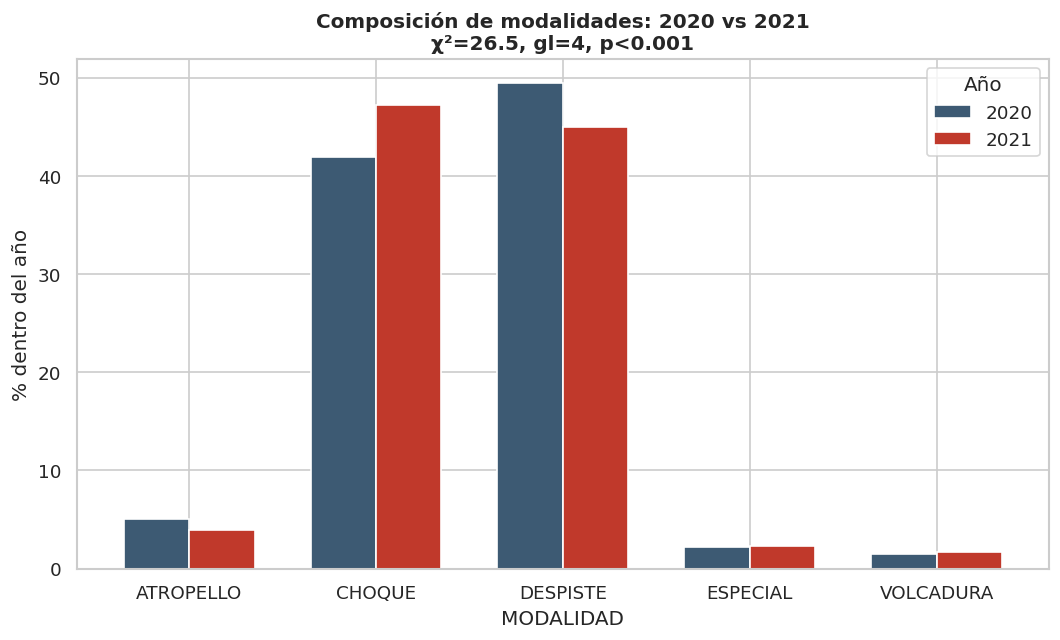

In [82]:
ct_year = pd.crosstab(df['MODALIDAD'], df['AÑO'], normalize='columns')*100
fig, ax = plt.subplots(figsize=(9, 5.5))
ct_year.plot(kind='bar', ax=ax, color=['#3D5A73','#C0392B'], edgecolor='white', width=0.7)
ax.set_title(f'Composición de modalidades: 2020 vs 2021\nχ²={chi2_a:.1f}, gl={gl_a}, p<0.001', fontweight='bold')
ax.set_ylabel('% dentro del año'); plt.xticks(rotation=0)
ax.legend(title='Año')
plt.tight_layout(); plt.show()
# Interpretación: CHOQUE incrementa su participación relativa en 2021 frente a DESPISTE.

## 9. Resumen de las 6 pruebas

| N° | Prueba | Estadístico | p-valor | Resultado |
|---|---|---|---|---|
| 1 | Chi² Modalidad × Gravedad | χ²=675.15 | <0.001 | Significativo |
| 2 | Kruskal-Wallis Heridos × Modalidad | H=212.37 | <0.001 | Significativo |
| 3 | Kruskal-Wallis Víctimas × Depto (Top10) | H=78.32 | <0.001 | Significativo |
| 4 | Chi² Franja pico × Con víctimas | χ²=0.51 | 0.476 | No significativo |
| 5 | Spearman Kilómetro × Víctimas | ρ=0.019 | 0.083 | No significativo |
| 6 | Chi² Modalidad × Año | χ²=29.95 | <0.001 | Significativo |

**Nota metodológica:** todas estas pruebas evalúan **asociación estadística**, no causalidad. Un resultado significativo (p<0.05) indica que dos variables no son independientes entre sí, pero no prueba mecánicamente que una cause a la otra.